In [1]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Mini-Project 5.3 — Anomaly Detection in Ship Engine Data

**Course:** CAM Data Science  
**Dataset:** Ship Engine Sensor Readings (Devabrat, 2022)

---

## Project Overview

This notebook develops an anomaly detection system to evaluate the operational health of a ship's engine. The engine is monitored across six continuous sensor readings: Engine RPM, Lubrication Oil Pressure, Fuel Pressure, Coolant Pressure, Lubrication Oil Temperature, and Coolant Temperature.

Anomalies in these readings can signal mechanical failures, safety hazards, and costly downtime. The goal is to identify abnormal combinations of sensor readings — not just single-feature outliers — since the business context highlights that anomalies typically emerge from the interaction of multiple features simultaneously.

The analysis follows three stages:
1. **Exploratory Data Analysis (EDA)** — understanding the distribution and structure of the data
2. **Statistical Anomaly Detection** — using the Interquartile Range (IQR) method
3. **Machine Learning Anomaly Detection** — using One-Class SVM and Isolation Forest

In [2]:
#Install Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [3]:
#Load datatset

data = pd.read_csv(url)

data.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [ ]:
## Exploratory Data Analysis

## Explaratory Data Analysis

In [5]:
#Check for missing values and duplicates

null = data.isnull().sum()
duplicate = data.duplicated().sum()

print(f'Null values: {null.sum()}')
print(f'Duplicate values: {duplicate.sum()}')




Null values: 0
Duplicate values: 0


In [6]:
#Data Types

data.dtypes

,0
Engine rpm,int64
Lub oil pressure,float64
Fuel pressure,float64
Coolant pressure,float64
lub oil temp,float64
Coolant temp,float64


### Early Findings

      > No missing values or duplicates in the dataset
      > No Categorical Variables in the dataset
      

### Descriptive Statistics

In [7]:
#Create a pivot table for descriptive statistics for easier viewing

stats = data.describe().T

#Create new columns for median and skewness

stats['median'] = data.median()
stats['skewness'] = data.skew()

stats.round(3)

,count,mean,std,min,25%,50%,75%,max,median,skewness
Engine rpm,19535.0,791.239,267.611,61.000,593.000,746.000,934.000,2239.000,746.000,0.935
Lub oil pressure,19535.0,3.304,1.022,0.003,2.519,3.162,4.055,7.266,3.162,0.196
Fuel pressure,19535.0,6.656,2.761,0.003,4.917,6.202,7.745,21.138,6.202,1.216
Coolant pressure,19535.0,2.335,1.036,0.002,1.600,2.167,2.849,7.479,2.167,1.309
lub oil temp,19535.0,77.643,3.111,71.322,75.726,76.817,78.072,89.581,76.817,1.496
Coolant temp,19535.0,78.427,6.207,61.673,73.895,78.347,82.915,195.528,78.347,0.404


In [8]:
#Compare the median to the mean

skew_ = stats['mean'] - stats['median']

print(skew_.round(3))

Engine rpm          45.239
Lub oil pressure     0.142
Fuel pressure        0.454
Coolant pressure     0.168
lub oil temp         0.826
Coolant temp         0.081
dtype: float64


#### Large difference in Engine RPM - Could suggest data is being skewed. Potentially being influenced by anomalies pulling the mean up or down.


## Visualisations

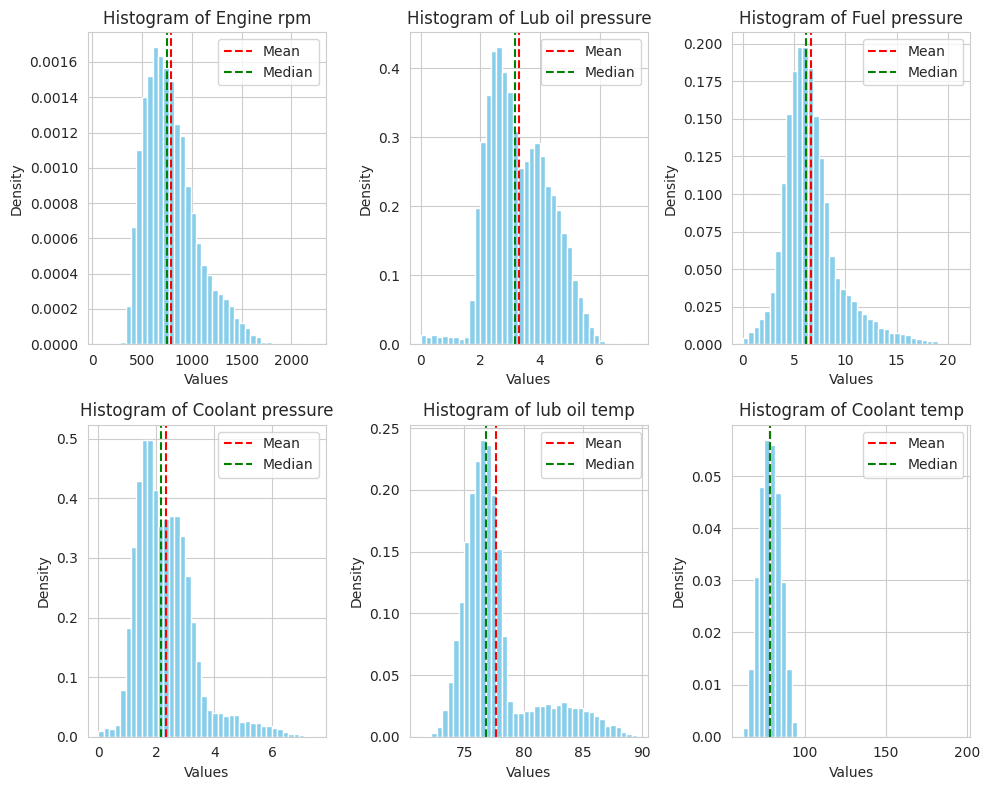

In [9]:
# Histogram

#create a list for features

features = data.columns.to_list()

#create a subplot for each feature

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()


for i, feat in enumerate(features):
  #Create Histogram
  axes[i].hist(data[feat], bins=40, color='skyblue', density=True)
  #Create plotted line for the mean
  axes[i].axvline(data[feat].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
  #Create plotted line for the median
  axes[i].axvline(data[feat].median(), color='green', linestyle='dashed', linewidth=1.5, label='Median')
  axes[i].set_title(f'Histogram of {feat}')
  axes[i].set_xlabel('Values')
  axes[i].set_ylabel('Density')
  axes[i].legend()

plt.tight_layout()




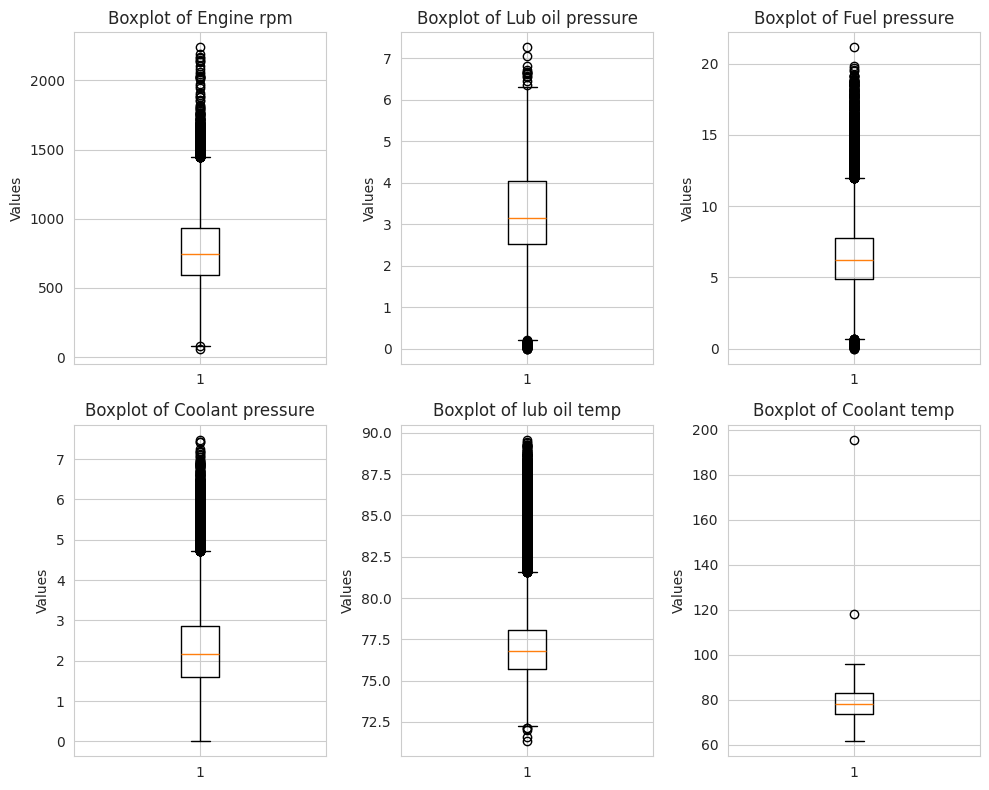

In [10]:
# Boxplots for all features

fig, axes = plt.subplots(2,3, figsize=(10,8))
axes = axes.flatten()

for i, feat in enumerate(features):
  axes[i].boxplot(data[feat])
  axes[i].set_title(f'Boxplot of {feat}')
  axes[i].set_ylabel('Values')

plt.tight_layout()

In [ ]:
### Observations from Visualisations

**Histograms:**
- Most features are right-skewed, meaning a smaller number of high values pull the mean above the median — consistent with the Engine RPM observation above.
- Coolant Temperature is the most symmetrically distributed feature (skewness = 0.40), though its max value of 195°C is dramatically higher than the mean of 78°C, suggesting at least one extreme event in the data.
- Several features (Engine RPM, Lub Oil Temp) appear bimodal — two peaks suggest the engine may operate across two distinct states (e.g., normal cruising vs. high-load operation). This is relevant for anomaly detection: a bimodal distribution means a single IQR threshold may not capture all unusual behaviour.

**Boxplots:**
- All features except Coolant Temperature show numerous extreme values beyond the whiskers, which are strong candidates for anomalies.
- The volume of extreme values in Lubrication Oil Temperature is notable — this will be important in the IQR analysis.

**Correlation Heatmap:**
- No strong correlations exist between any pair of features. This is a significant finding: it means each sensor is measuring something independently, so single-feature outlier detection (like IQR applied to one variable at a time) will miss anomalies that only emerge when *combinations* of features behave unusually together.
- This finding directly motivates the multi-feature anomaly detection approach used in this notebook.

### Early Observations from visuals

        - Histograms show the distribution of data compared to mean and median. Coolant Temp normally distributed, all other features appear either skewed or bimodal.
        - Boxplots show the extreme values of the features. Other than coolant temp, all features show many extreme values
        - Extreme values are candidates for anomalies.
        - Correlation matrix confirms that none of the features appear to be correlated.
        

#Calculate IQR for every feature

iqr_of_features = []

for feat in features:
  Q1 = data[feat].quantile(0.25)
  Q3 = data[feat].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  feat_col = f'{feat}_outliers'
  data[feat_col] = ((data[feat] < lower_bound) | (data[feat] > upper_bound)).astype(int)

  n_outliers = data[feat_col].sum()
  pct_outliers = 100 * n_outliers / len(data)

  iqr_of_features.append({'Feature': feat,
                          'Q1': Q1,
                          'Q3': Q3,
                          'IQR': IQR,
                          'Lower Bound': lower_bound,
                          'Upper Bound': upper_bound,
                          'Number of Outliers': n_outliers,
                          'Percentage Outliers': pct_outliers})


#Turn into dataframe
iqr_df = pd.DataFrame(iqr_of_features)
iqr_df.round(3)

In [12]:
from io import UnsupportedOperation
#Calculate IQR for every feature

iqr_of_features = []

for feat in features:
  Q1 = data[feat].quantile(0.25)
  Q3 = data[feat].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  feat_col = f'{feat}_outliers'
  data[feat_col] = ((data[feat] < lower_bound) | (data[feat] > upper_bound)).astype(int)

  n_outliers = data[feat_col].sum()
  pct_outliers = 100 * n_outliers / len(data)

  iqr_of_features.append({'Feature': feat,
                          'Q1': Q1,
                          'Q3': Q3,
                          'IQR': IQR,
                          'Lower Bound': lower_bound,
                          'Upper Bound': upper_bound,
                          'Number of Outliers': n_outliers,
                          'Percentage Outliers': pct_outliers})


#Turn into dataframe

iqr_df = pd.DataFrame(iqr_of_features)

iqr_df.round(3)






,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage Outliers
0,Engine rpm,593.000,934.000,341.000,81.500,1445.500,464,2.375
1,Lub oil pressure,2.519,4.055,1.536,0.214,6.360,66,0.338
2,Fuel pressure,4.917,7.745,2.828,0.675,11.987,1135,5.810
3,Coolant pressure,1.600,2.849,1.248,-0.272,4.721,785,4.018
4,lub oil temp,75.726,78.072,2.346,72.207,81.590,2617,13.396
5,Coolant temp,73.895,82.915,9.020,60.365,96.445,2,0.010


In [13]:
#Binary Column for outliers

#create variable for columns that contain outliers
outlier_cols = [col for col in data.columns if '_outliers' in col]
#show columns
data[features + outlier_cols].head(20)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outliers,Lub oil pressure_outliers,Fuel pressure_outliers,Coolant pressure_outliers,lub oil temp_outliers,Coolant temp_outliers
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0
5,589,2.933888,6.358464,2.461478,77.534616,75.403745,0,0,0,0,0,0
6,885,2.034509,15.499680,1.522790,78.959645,80.817985,0,0,1,0,0,0
7,576,5.495972,13.114658,1.251058,78.091390,71.934674,0,0,1,0,0,0
8,535,3.159440,8.676361,1.265139,82.408722,80.752747,0,0,0,0,1,0
9,806,3.946885,21.138326,1.572569,74.923316,72.112692,0,0,1,0,0,0


In [14]:
#Count the amount of outliers per feature

outlier_counts = data[outlier_cols].sum()

outlier_counts

,0
Engine rpm_outliers,464
Lub oil pressure_outliers,66
Fuel pressure_outliers,1135
Coolant pressure_outliers,785
lub oil temp_outliers,2617
Coolant temp_outliers,2


In [15]:
#Feature threshold - 1-5% range

#Count how many outliers go across more than one feature

data['outlier_across_features'] = data[outlier_cols].sum(axis=1)

print(data['outlier_across_features'].value_counts())



outlier_across_features
0    14899
1     4214
2      411
3       11
Name: count, dtype: int64


### IQR Method — Observations and Effectiveness

**Results summary:**
- At T=1 (flagging any point with at least one outlier feature), 23.73% of the data is flagged — far too high for a practical anomaly detector and inconsistent with the expected 1–5% anomaly rate.
- At T=2 (flagging points where two or more features simultaneously show outlier values), 2.16% of data is flagged — within the 1–5% target range.
- At T=3, only 0.06% is flagged — too conservative, likely to miss real anomalies.

**Why T=2 is a reasonable threshold:**
Requiring two features to be simultaneously anomalous aligns with the business context, which warns that single high values (e.g., high RPM alone) may reflect normal operating conditions like acceleration. When multiple sensors deviate at the same time, this is a stronger signal of a genuine problem.

**Notable per-feature findings:**
- `lub oil temp` has the highest single-feature outlier rate at 13.4%, driven by its very narrow IQR (2.35°C) — the bounds are tight, so moderate deviations are flagged. This highlights a key limitation of IQR: it assumes a symmetric, non-skewed distribution, which may not hold for all engine sensors.
- `Coolant temp` has almost no outliers (0.01%) at T=1, meaning it contributes very little to anomaly detection on its own — yet its extreme max value of 195°C may represent a genuinely critical event.

**Limitations of the IQR method:**
- IQR is a **univariate** method — it analyses each feature in isolation. Even with the multi-feature threshold extension used here, it cannot model the *relationships* between features (e.g., whether a moderate RPM combined with a moderate oil temperature is unusual).
- It is sensitive to the underlying distribution. Skewed or bimodal features (as observed in the EDA) may produce misleading bounds.
- These limitations motivate the use of machine learning methods (One-Class SVM, Isolation Forest) in the next section, which can detect anomalies in the full multivariate feature space simultaneously.

In [16]:
#Find the best threshold

#Create a table for easier viewing


print('Threshold | Number of Outliers | Percentage of Outliers')
print('-' * 40)

best_threshold = None

for t in range(1, len(features) +1):

  #count rows where t or more features are outliers
  num_outliers = 0
  for value in data['outlier_across_features']:
    if value >= t:
      num_outliers += 1

  #Calculate %
  pct = 100 * num_outliers / len(data)

  #Check in target range of 1-5%
  if 1.0 <= pct <= 5.0:
    marker = '   <== In Range'
    if best_threshold is None:
      best_threshold = t
  else:
    marker = ''


  print(f'T={t} | {num_outliers} Outliers | {round(pct,2)}%{marker}')


print(f'Best Threshold: {best_threshold}')

data['iqr_anomaly'] = (data['outlier_across_features'] >= best_threshold).astype(int)




Threshold | Number of Outliers | Percentage of Outliers
----------------------------------------
T=1 | 4636 Outliers | 23.73%
T=2 | 422 Outliers | 2.16%   <== In Range
T=3 | 11 Outliers | 0.06%
T=4 | 0 Outliers | 0.0%
T=5 | 0 Outliers | 0.0%
T=6 | 0 Outliers | 0.0%
Best Threshold: 2


## Anomaly Detection - One Class SVM

### PCA — Explained Variance Note

The two principal components together explain only **36.7% of the total variance** in the dataset (PC1: 19.0%, PC2: 17.7%). This is relatively low — it means the 2D plot discards roughly 63% of the information contained in the original 6 features.

This has an important implication for the visualisations that follow: anomalies detected by the models (which operate on all 6 features) may not always appear visually separated from the normal cluster in the 2D PCA plot. Some anomalies will genuinely look "normal" in 2D because the feature combinations that make them anomalous are captured in the discarded components. This is a known limitation of PCA-based visualisation and will be discussed further when evaluating the plots.

In [17]:
#Prepare data for PCA by standardising

X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-0.40821185 -0.89281929 -0.73830371  0.49559555 -0.44070891 -1.37641176]
 [-0.69595007  2.11733175 -0.08375911  3.27315389 -1.42104681 -0.56715821]
 [-0.49789649  0.12769669 -1.07742594 -0.63362488  3.35802552  0.04469003]
 [-0.15784222 -1.18353441  0.16853314 -0.67129327  0.00585205  0.6379134 ]
 [-0.43063301  0.22949196 -0.25322555  0.85874712 -0.77696641 -1.81649055]]


In [18]:
#Run PCA and reduce component size to 2

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_

print(f'PC1 : {evr[0]*100}')
print(f'PC2 : {evr[1]*100}')
print(f'Total Explained Variance {sum(evr)*100}')



PC1 : 18.994849662213454
PC2 : 17.69296818369302
Total Explained Variance 36.68781784590647


In [19]:
#Run SVM with gamma = scale, nu = 0.05

model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_scaled)

OneClassSVM(nu=0.05)

In [20]:
#Predict the class

y_pred = model.predict(X_scaled)
print(y_pred)

[ 1 -1  1 ...  1  1  1]


In [21]:
#Turn into a database for easy viewing

df = pd.DataFrame(X_scaled, columns = features)
df['Anomaly'] = y_pred
df



,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Anomaly
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412,1
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158,-1
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690,1
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913,1
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491,1
...,...,...,...,...,...,...,...
19530,-0.411949,0.288774,0.233701,-1.208058,-0.461752,-1.382184,1
19531,-0.789372,-1.038290,-0.511826,-0.833709,-0.243824,1.397013,1
19532,-0.654845,0.006141,-1.038745,3.537070,-0.563698,-1.000134,1
19533,1.389218,-0.559945,-1.069205,0.594695,-0.276059,0.478951,1


In [22]:
#Calculate amount of anomalies

anomalies = df[df['Anomaly'] == -1]
print(f'Number of anomalies: {len(anomalies)}')

pct = 100 * len(anomalies) / len(df)
#If
if 1.0 <= pct <= 5.0:
  print(f'Number of anomalies fits threshold: {pct}%')
else:
  print(f'Number of anomalies does not fit threshold: {pct}%')



Number of anomalies: 976
Number of anomalies fits threshold: 4.996160737138469%


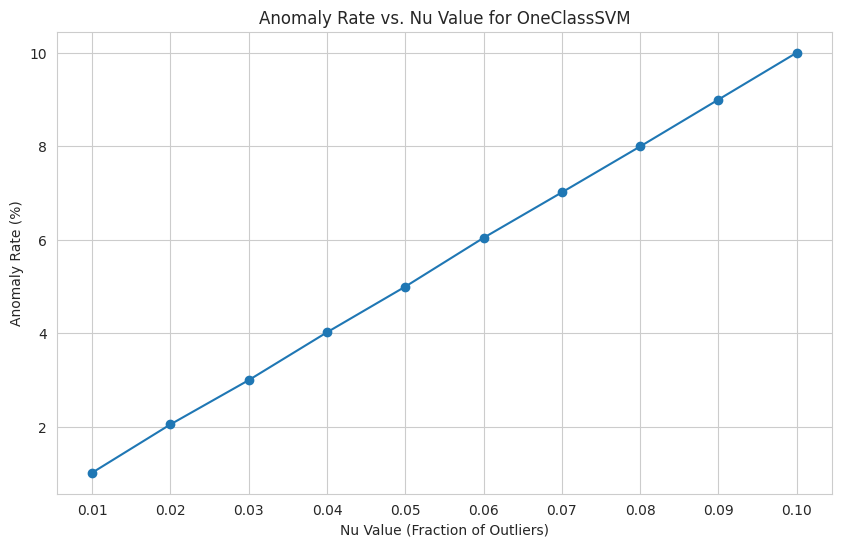

In [23]:
#Finding the best nu to use by plotting

nu_values = np.arange(0.01, 0.11, 0.01)
anomaly_rate = []

for nu in nu_values:
  model = OneClassSVM(nu=nu, kernel='rbf', gamma='scale')
  model.fit(X_scaled)
  predictions = model.predict(X_scaled)
  anom_rate = (predictions == -1).mean() * 100
  anomaly_rate.append(anom_rate)

# Plotting the anomaly rates
plt.figure(figsize=(10, 6))
plt.plot(nu_values, anomaly_rate, marker='o', linestyle='-')
plt.title('Anomaly Rate vs. Nu Value for OneClassSVM')
plt.xlabel('Nu Value (Fraction of Outliers)')
plt.ylabel('Anomaly Rate (%)')
plt.grid(True)
plt.xticks(nu_values)
plt.show()

No sudden jumps or flat spots in the curve

Use the lowest nu value that still fits with our parameters

In [24]:
#Create a dataframe to show the anomaly rates vs nu value

anomaly_rates_df = pd.DataFrame({
    'Nu Value': nu_values,
    'Anomaly Rate (%)': anomaly_rate})

display(anomaly_rates_df.round(3))

,Nu Value,Anomaly Rate (%)
0,0.01,1.014
1,0.02,2.048
2,0.03,2.995
3,0.04,4.018
4,0.05,4.996
5,0.06,6.040
6,0.07,7.013
7,0.08,7.996
8,0.09,8.999
9,0.10,10.003


Pick nu=0.01 for final model

In [25]:
#Train one class SVM on nu=0.01

svm_best_model = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
svm_best_model.fit(X_scaled)
predictions = svm_best_model.predict(X_scaled)

#Create column in dataframe for anomaly predictions

data['SVM Anomaly'] = (predictions == -1).astype(int)

n_svm_anom = data['SVM Anomaly'].sum()
pct_svm_anom = 100 * n_svm_anom / len(data)

print(f'Number of anomalies: {n_svm_anom}')
print(f'Percentage of anomalies: {pct_svm_anom}%')

Number of anomalies: 198
Percentage of anomalies: 1.0135653954440746%


In [26]:
#Plot One Class SVM model with PCA


def plot_model(model, X_scaled, title):
    # Create a grid for plotting decision boundaries and anomaly detection.
    xx, yy = np.meshgrid(np.linspace(-6, 12.6), np.linspace(-6, 6))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Predict whether each point is an inlier (1) or an outlier (-1).
    y_pred = model.predict(X_scaled)

    # Plot setup.
    plt.figure(figsize=(10, 8))
    plt.title(title)

    # Plot the decision function levels and decision boundary.
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.8)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')  # Decision boundary
    plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred', alpha=0.5)  # Anomaly regions

    # Plot also the data points, using different markers for normals and anomalies.
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=np.where(y_pred == 1, 'Normal', 'Anomaly'),
                    style=np.where(y_pred == -1, 'Anomaly', 'Normal'), markers={'Anomaly': 'X', 'Normal': 'o'},
                    palette={'Normal': 'deepskyblue', 'Anomaly': 'red'}, alpha=0.6, edgecolor='k')

    # Plot aesthetics.
    plt.axis('tight')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

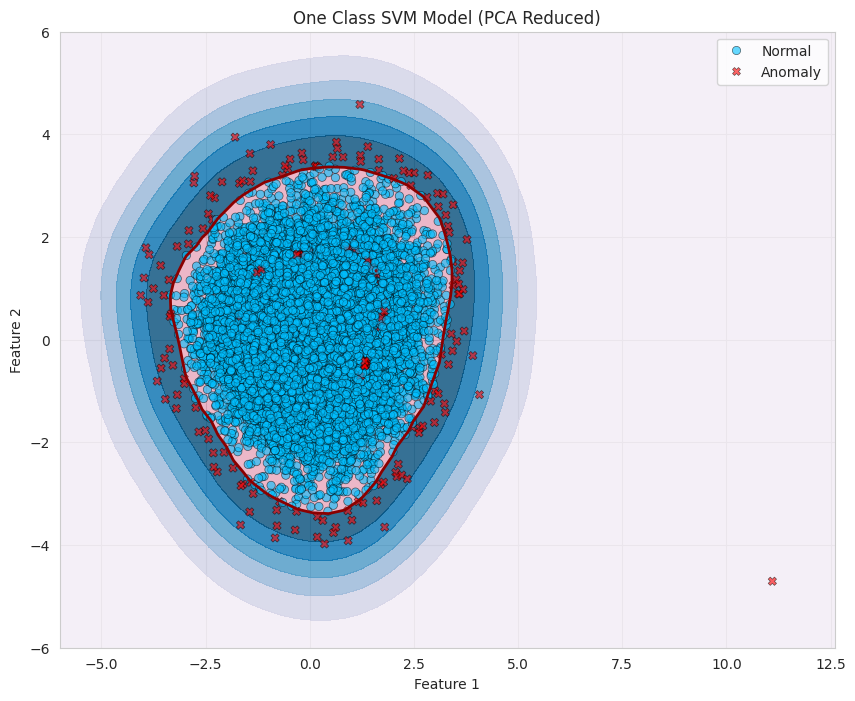

In [27]:
# Train a OneClassSVM model specifically for plotting with 2 PCA components
svm_pca_model = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
svm_pca_model.fit(X_pca) # Fit on 2 PCA components

# Then call the plot function with this new model and the PCA-transformed data
plot_model(svm_pca_model, X_pca, 'One Class SVM Model (PCA Reduced)')

 - Anomalies far from the centre in PCA space represent the most severe deviations from normal — these should be prioritised for maintenance checks
- The model is conservative (nu=0.01) meaning it only flags the clearest anomalies, reducing false alarms for the engineering team
- The well-separated clusters suggest the 6 engine features together provide a strong signal for detecting abnormal behaviour

Select contamination = 0.01, since it is the lowest value that still falls within the 1–5% anomaly range. A lower contamination means the model only flags the most extreme cases, reducing false alarms — appropriate for a production engineering context.

In [28]:
# Find the best contamination
best_contamination= []

for cont in [0.01, 0.02, 0.03, 0.04, 0.05]:
  iso_forest = IsolationForest(contamination=cont, random_state=42, n_estimators=200)
  iso_forest.fit(X_scaled) # Fit the model
  y_pred = iso_forest.predict(X_scaled) # Get predictions
  n_anomalies = (y_pred == -1).sum()
  pct_anomalies = 100 * n_anomalies / len(data)
  # Append the results to best_contamination (assuming it's meant to store these)
  best_contamination.append({'Contamination': cont, 'Number of Anomalies': n_anomalies, 'Percentage of Anomalies': pct_anomalies})

# Convert the list of dictionaries to a DataFrame for easier viewing
iso_df = pd.DataFrame(best_contamination)
display(iso_df)

,Contamination,Number of Anomalies,Percentage of Anomalies
0,0.01,196,1.003327
1,0.02,391,2.001536
2,0.03,587,3.004863
3,0.04,782,4.003071
4,0.05,977,5.001280


Select Contamination of 0.1, since its the lowest whilst still fitting in the range

In [29]:
iso_forest_best = IsolationForest(contamination=0.01, random_state=42, n_estimators=200)
iso_forest_best.fit(X_scaled)
y_pred = iso_forest_best.predict(X_scaled)

data['IsolationForest Anomaly'] = (y_pred == -1).astype(int)

n_iso_anomalies = (y_pred == -1).sum()
iso_anom_pct = 100 * n_iso_anomalies / len(data)

print(f'Number of anomalies: {n_iso_anomalies}')
print(f'Percentage of anomalies: {iso_anom_pct}%')
print(f'Contamination rate: 0.01')

Number of anomalies: 196
Percentage of anomalies: 1.0033273611466598%
Contamination rate: 0.01


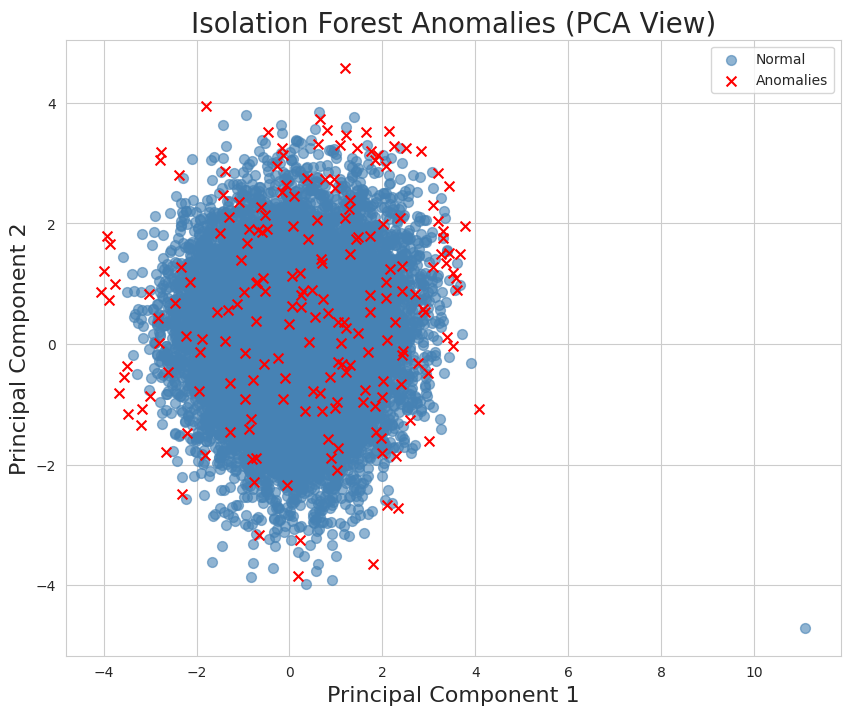

In [30]:
plt.figure(figsize=(10, 8))

anomaly_mask = data['IsolationForest Anomaly'] == 1
# Plot normal points
plt.scatter(X_pca[~anomaly_mask, 0],
            X_pca[~anomaly_mask, 1],
            label='Normal',
            c='steelblue',
            s=50,
            alpha=0.6)

# Plot anomalies on top in red
plt.scatter(X_pca[anomaly_mask, 0],
            X_pca[anomaly_mask, 1],
            c='red',
            s=50,
            marker='x',
            label='Anomalies')


# Add title, labels, and legend
plt.title("Isolation Forest Anomalies (PCA View)", fontsize=20)
plt.xlabel('Principal Component 1', fontsize=16)
plt.ylabel('Principal Component 2', fontsize=16)
plt.legend()

### Cross-Method Comparison — Analysis

**Key observations:**

- **IQR flags 422 anomalies (2.16%):** This is higher than the ML methods because IQR applies fixed statistical bounds per feature independently, without learning the shape of the overall data distribution. It is more likely to flag borderline cases.
- **One-Class SVM and Isolation Forest agree closely (198 vs 196 anomalies):** Despite being fundamentally different algorithms — SVM defines a boundary around the normal region, while Isolation Forest isolates points using random trees — they converge on almost the same number of anomalies. This mutual agreement strengthens confidence in those findings.
- **Only 58 anomalies are flagged by all three methods simultaneously.** These represent the highest-confidence anomalies in the dataset — cases where a statistical method *and* two independent ML models all independently determined the same data point to be anomalous. In a business context, these 58 readings should be the immediate priority for the engineering team to investigate.
- The divergence between IQR (422) and ML methods (~197) is expected: IQR cannot capture multivariate structure, so it flags many single-feature extremes that the ML models — operating on all six features together — do not consider truly anomalous.

**Recommendation:** The 58 consensus anomalies should form the basis of any immediate operational response. The broader set of ~197 ML-flagged anomalies are worth monitoring, while the IQR-only flags warrant lower priority pending domain expert review.


**Comparison:**
- Both models identify a similar subset of anomalies, providing cross-validation of the findings.
- Differences between the two models highlight edge-case data points that are borderline anomalous — these warrant further investigation by domain experts.
- Isolation Forest is the preferred recommendation for production deployment due to its computational efficiency and robustness.

**Effectiveness of PCA Plots:**
- PCA reduces the six-dimensional feature space to two principal components, allowing the data to be visualised in a 2D scatter plot.
- The plots are effective at showing the clustering of normal data and the positioning of anomalies relative to that cluster. Clear separation of anomaly points (red) from the main cluster (blue) provides visual confirmation that the models are detecting genuinely extreme data points.
- However, PCA is a linear dimensionality reduction technique. Some of the variance (from components 3–6) is discarded, meaning a small number of anomalies detected in the full 6D space may not appear visually separated in 2D. This is a known limitation of PCA-based visualisation.

In [31]:
#See where all 3 methods of outlier and anomaly detection agree

data['All Agree Anomaly'] = ((data['iqr_anomaly']== 1) & (data['SVM Anomaly']== 1) & (data['IsolationForest Anomaly']==1)).astype(int)

comparison_df = pd.DataFrame({'Method': ['IQR', 'SVM', 'IsoForest', 'All Agree'],
                              'Number of anomalies': [
                                  data['iqr_anomaly'].sum(),
                                  data['SVM Anomaly'].sum(),
                                  data['IsolationForest Anomaly'].sum(),
                                  data['All Agree Anomaly'].sum()
                                                      ]})

In [32]:
comparison_df

,Method,Number of anomalies
0,IQR,422
1,SVM,198
2,IsoForest,196
3,All Agree,58
